# 5.1 — Linear Regression
### The Foundation of All Regression Algorithms

---

## The Analogy

Imagine **Ravi** is a real estate agent in Kochi. He has seen hundreds of flats over 10 years. Over time, he developed a gut feeling:

- *"Every extra 100 sqft adds roughly ₹3,000 to rent"*
- *"Every km closer to MG Road adds ₹1,500"*
- *"Older buildings are cheaper — each year of age cuts ₹500"*

Ravi doesn't have a formula written down. He just **learned these relationships from experience**.

**Linear Regression is doing exactly what Ravi does — but mathematically, from data.**

It looks at thousands of examples and learns: *"how much does each feature contribute to the final number I'm trying to predict?"*

---

## What Problem Are We Solving?

We want to **predict a continuous number** — not a category.

| Task | Output Type | Algorithm |
|------|-------------|----------|
| Is this email spam? | Category (Yes/No) | Classification |
| What will this flat rent for? | Number (₹32,000) | **Regression** |
| Will this customer churn? | Category (Yes/No) | Classification |
| What will next month's sales be? | Number (4,200 units) | **Regression** |

Linear Regression is the **first model to try** for any regression problem — just like Logistic Regression is the first model for classification.

---

## The Equation

$$\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b$$

| Symbol | Name | Meaning |
|--------|------|---------|
| $\hat{y}$ | Predicted value | The rent/price we are guessing |
| $x_1, x_2...$ | Features | area, distance, age, floor... |
| $w_1, w_2...$ | Coefficients/Weights | How much each feature matters |
| $b$ | Intercept | Base value when all features = 0 |

**In Ravi's language:**
```
rent = 30×area + 1500×closeness_to_MG - 500×age + 8000
         ↑           ↑                     ↑         ↑
        w₁           w₂                   w₃         b
```

---

## What Does "Linear" Actually Mean?

Linear does NOT mean "only works with straight lines on a graph."

It means: **each feature has a proportional relationship with the output.**

- Double the area → double the area's contribution to rent
- Triple the distance → triple the distance's contribution
- No curves, no exponentials — just multiplication and addition

With **1 feature** → straight line on a 2D graph  
With **2 features** → flat plane in 3D space  
With **n features** → hyperplane in n-dimensional space (same idea, higher dimensions)

---

## The Core Question: What Are We Finding?

We have the equation structure. But we don't know $w_1, w_2, b$ yet.

**Finding the best values of w and b = the entire job of Linear Regression.**

"Best" = the values that make our predictions as close to reality as possible across ALL training examples.

---

## How Do We Measure "Close to Reality"? — MSE

We use **Mean Squared Error (MSE):**

$$MSE = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

| Part | Meaning |
|------|---------|
| $y_i$ | Actual value for row i (real rent) |
| $\hat{y}_i$ | Predicted value for row i (our guess) |
| $(y_i - \hat{y}_i)$ | Error for that row |
| Squared | So positive and negative errors don't cancel |
| $\frac{1}{n}$ average | So dataset size doesn't distort the result |

**Why square the error?**

1. **Sign problem** — if one prediction is +₹5,000 off and another is -₹5,000 off, they'd cancel to zero. That's wrong — both are bad. Squaring makes both positive.
2. **Punishes big errors harder** — error of 10 → penalty of 100. Error of 100 → penalty of 10,000. The model is forced to fix large mistakes first.

---

## How Does the Model Find the Best w and b?

### Method 1 — Normal Equation (what sklearn uses by default)

$$w = (X^TX)^{-1}X^Ty$$

This is pure linear algebra. **No iteration. No guessing.** It solves for the exact best coefficients in one shot.

- $X^T$ = transpose of feature matrix (just flipping rows/columns — cheap)
- $(X^TX)^{-1}$ = **matrix inversion** — this is the expensive part
- For n features, inversion costs $O(n^3)$
  - 100 features → 1,000,000 operations → fast
  - 10,000 features → 1,000,000,000,000 operations → impossible

**When sklearn calls `.fit()`, this is what runs behind the scenes.**

---

## Two Different `.fit()` Calls — Same Name, Different Jobs

sklearn uses `.fit()` as a consistent naming convention — *"learn something from this data."* But what it learns depends entirely on which object you call it on.

**`scaler.fit(X)`** — StandardScaler's fit. Computes the mean and std of each feature and stores them. Then `.transform()` applies `(x - mean) / std`. Nothing to do with predictions.

**`model.fit(X, y)`** — LinearRegression's fit. Has nothing to do with scaling. This solves the Normal Equation:
```
w = (XᵀX)⁻¹Xᵀy
```
Finds the best weights that minimise sum of squared errors. Pure linear algebra — one shot, no iteration.

```python
scaler = StandardScaler()
scaler.fit(X)      # learns mean and std of each feature — for scaling

model = LinearRegression()
model.fit(X, y)    # solves normal equation — finds best coefficients
```

Same method name. Completely different objects. Completely different jobs.

---

### Method 2 — Gradient Descent (used for large datasets)

1. Start with random w and b
2. Make predictions with current values
3. Calculate MSE — how wrong are we?
4. Calculate the gradient — which direction reduces MSE?
5. Nudge w and b slightly in that direction
6. Repeat until MSE stops improving

Update rule at every step:
$$w = w - \alpha \cdot \frac{\partial MSE}{\partial w}$$

Where $\alpha$ = learning rate (how big each nudge is)

| | Normal Equation | Gradient Descent |
|---|---|---|
| How | Solves directly in one shot | Iterates step by step |
| Speed on small data | Very fast | Slower |
| Speed on large data | Breaks down ($O(n^3)$) | Handles it fine |
| sklearn class | `LinearRegression` | `SGDRegressor` |

---

## The Overfitting Problem

Linear Regression has **no restrictions** on coefficient size. Given enough features, it will assign whatever w values perfectly fit the training data — even if those values are absurd like w = 50,000.

Result:
- Training MSE → very low (memorised everything)
- Test MSE → very high (useless on new data)

**This is exactly the problem Ridge Regression (5.2) was built to fix.**

---

## Assumptions Linear Regression Makes

| Assumption | Meaning | What breaks if violated |
|------------|---------|------------------------|
| Linearity | Each feature has proportional relationship with output | Predictions systematically wrong |
| No multicollinearity | Features shouldn't be highly correlated | Coefficients become wild and unstable |
| Homoscedasticity | Error size consistent across predictions | Confidence intervals unreliable |
| Normality of errors | Errors roughly normally distributed | Statistical tests break down |

---

## Real World Problem — Bangalore Flat Price Prediction

**Priya** works at a real estate firm in Bangalore. She has data on 5,000 flats and wants to build a model that predicts flat prices (₹ lakhs) so her team can give instant quotes to customers.

**Features available:**
- `area_sqft` — size of the flat
- `distance_from_metro_km` — distance to nearest metro station
- `age_years` — how old the building is
- `floor_number` — which floor the flat is on
- `locality_rating` — neighbourhood quality score (1-10)

**Target:** `price_lakhs`

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# WHY these imports:
# numpy/pandas     — data creation and manipulation
# LinearRegression — sklearn's implementation (uses Normal Equation internally)
# train_test_split — split data so we can test on unseen examples
# metrics          — MSE, MAE, R² to evaluate how good our model is
# StandardScaler   — not strictly needed for Linear Regression but good habit

np.random.seed(42)  # WHY: makes random data reproducible — same numbers every run

In [2]:
# ── Step 1: Create Synthetic Bangalore Flat Dataset ───────────────────────────
n = 500  # 500 flats

area_sqft            = np.random.randint(400, 2500, n)
distance_from_metro  = np.round(np.random.uniform(0.5, 15, n), 1)
age_years            = np.random.randint(0, 30, n)
floor_number         = np.random.randint(1, 20, n)
locality_rating      = np.random.randint(1, 11, n)

# WHY create synthetic data?
# We know the TRUE relationship — so we can verify the model learned it correctly.

# TRUE price formula (what we want the model to discover):
noise = np.random.normal(0, 3, n)

price_lakhs = (
    0.04  * area_sqft +
   -1.5   * distance_from_metro +
   -0.6   * age_years +
    0.3   * floor_number +
    2.5   * locality_rating +
    10    +
    noise
)

df = pd.DataFrame({
    'area_sqft':           area_sqft,
    'distance_from_metro': distance_from_metro,
    'age_years':           age_years,
    'floor_number':        floor_number,
    'locality_rating':     locality_rating,
    'price_lakhs':         np.round(price_lakhs, 2)
})

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 6)


,area_sqft,distance_from_metro,age_years,floor_number,locality_rating,price_lakhs
0,1260,5.4,18,4,9,69.52
1,1694,3.0,29,9,9,81.69
2,1530,9.9,5,6,1,64.17
3,1495,6.1,1,16,3,75.17
4,2038,3.8,11,2,4,91.47


In [3]:
# ── Step 2: Explore the Data ─────────────────────────────────────────────────
print("Basic statistics:")
print(df.describe().round(2))
print("\nAverage flat price: ₹", round(df['price_lakhs'].mean(), 2), "lakhs")
print("Price range: ₹", round(df['price_lakhs'].min(), 2), "to ₹", round(df['price_lakhs'].max(), 2), "lakhs")

Basic statistics:
       area_sqft  distance_from_metro  age_years  floor_number  \
count     500.00               500.00     500.00        500.00   
mean     1486.02                 7.86      15.11          9.80   
std       575.64                 4.02       8.73          5.43   
min       401.00                 0.50       0.00          1.00   
25%      1031.50                 4.47       8.00          5.00   
50%      1520.50                 8.10      15.00         10.00   
75%      1980.50                11.30      23.00         14.00   
max      2494.00                15.00      29.00         19.00   

       locality_rating  price_lakhs  
count           500.00       500.00  
mean              5.52        65.45  
std               2.82        25.02  
min               1.00         4.89  
25%               3.00        45.46  
50%               5.00        65.65  
75%               8.00        85.32  
max              10.00       124.41  

Average flat price: ₹ 65.45 lakhs
Price rang

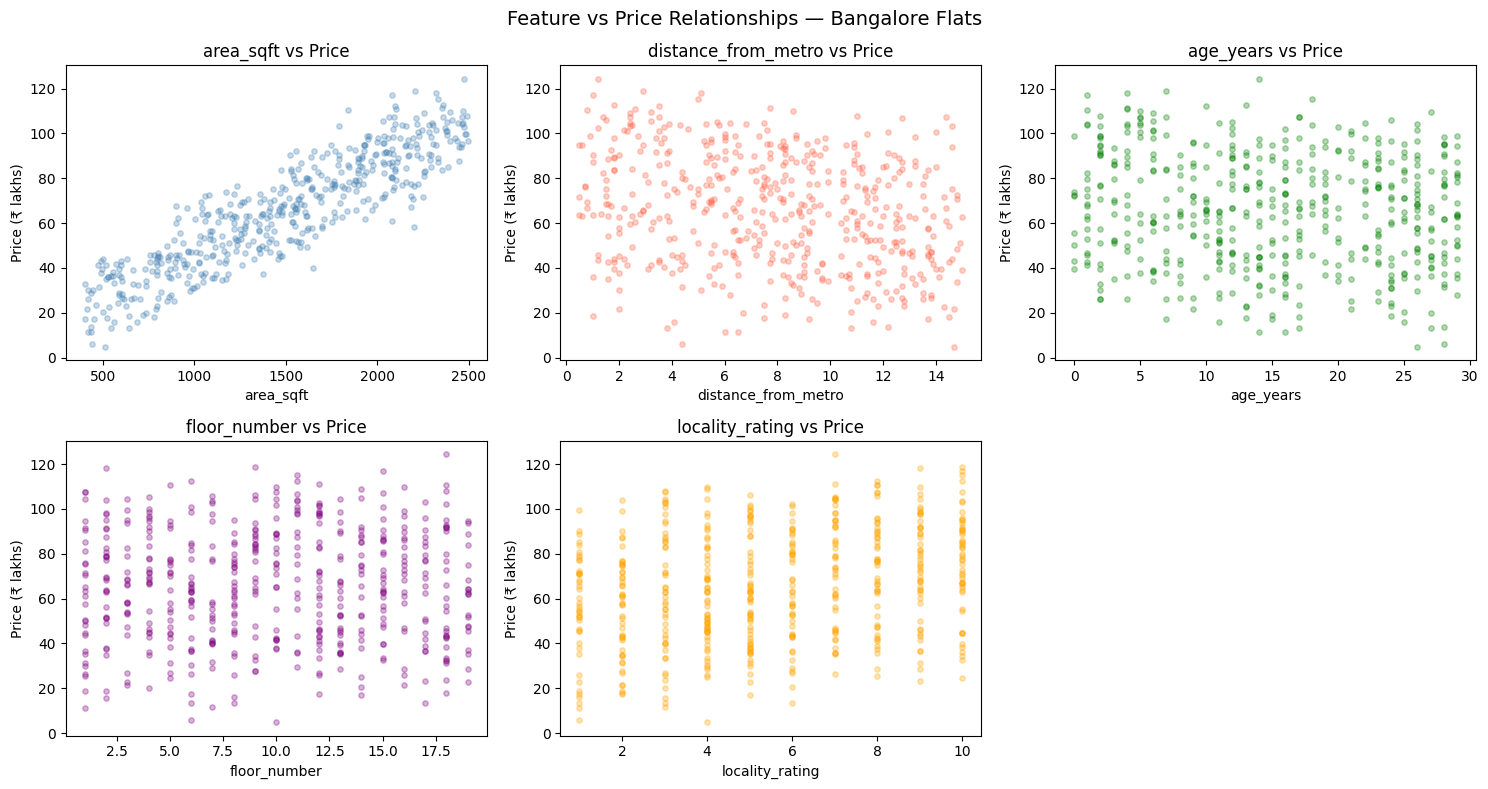

In [4]:
# ── Step 3: Visualise Relationships ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature vs Price Relationships — Bangalore Flats', fontsize=14)

features = ['area_sqft', 'distance_from_metro', 'age_years', 'floor_number', 'locality_rating']
colors   = ['steelblue', 'tomato', 'green', 'purple', 'orange']

for i, (feat, color) in enumerate(zip(features, colors)):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[feat], df['price_lakhs'], alpha=0.3, color=color, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('Price (₹ lakhs)')
    ax.set_title(f'{feat} vs Price')

axes[1][2].axis('off')
plt.tight_layout()
plt.show()

In [5]:
# ── Step 4: Split Data ────────────────────────────────────────────────────────
X = df.drop('price_lakhs', axis=1)
y = df['price_lakhs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} flats")
print(f"Test set:     {X_test.shape[0]} flats")

Training set: 400 flats
Test set:     100 flats


In [6]:
# ── Step 5: Train the Model ───────────────────────────────────────────────────
model = LinearRegression()
# WHY LinearRegression()?
# Creates an empty model — no coefficients yet, just the structure.
# Internally uses the Normal Equation: w = (XᵀX)⁻¹Xᵀy

model.fit(X_train, y_train)
# WHY model.fit() — not scaler.fit()?
# IMPORTANT: there are two completely different .fit() calls in sklearn:
#
#   scaler.fit(X)     → StandardScaler's fit
#                        Learns mean and std of each feature — for scaling only
#                        Then .transform() applies (x - mean) / std
#
#   model.fit(X, y)   → LinearRegression's fit
#                        Has NOTHING to do with scaling
#                        Solves: w = (XᵀX)⁻¹Xᵀy
#                        Finds best weights to minimise sum of squared errors
#                        Pure linear algebra — exact solution, one shot, no iteration
#
# sklearn uses .fit() as a consistent convention — "learn something from this data"
# What it learns depends entirely on which object you call it on.

print("Training complete!")
print("\nWhat the model learned:")
print(f"  Intercept (b)         : {model.intercept_:.2f} lakhs")
print()
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat:<25}: {coef:.4f}")

print("\n--- TRUE values we used to generate data ---")
print("  area_sqft             : 0.0400")
print("  distance_from_metro   : -1.5000")
print("  age_years             : -0.6000")
print("  floor_number          : 0.3000")
print("  locality_rating       : 2.5000")
print("  intercept             : 10.00")

Training complete!

What the model learned:
  Intercept (b)         : 10.13 lakhs

  area_sqft                : 0.0397
  distance_from_metro      : -1.4513
  age_years                : -0.6005
  floor_number             : 0.3335
  locality_rating          : 2.4429

--- TRUE values we used to generate data ---
  area_sqft             : 0.0400
  distance_from_metro   : -1.5000
  age_years             : -0.6000
  floor_number          : 0.3000
  locality_rating       : 2.5000
  intercept             : 10.00


In [7]:
# ── Step 6: Make Predictions ──────────────────────────────────────────────────
y_pred = model.predict(X_test)
# WHY .predict()?
# Applies learned w and b: ŷ = w₁x₁ + w₂x₂ + ... + b for each test row
# No learning happens here — just applying what was learned in .fit()

print("Sample predictions vs actual:")
print(f"{'Actual':>10} {'Predicted':>10} {'Error':>10}")
print("-" * 35)
for actual, pred in zip(y_test[:8], y_pred[:8]):
    print(f"₹{actual:>8.2f}L  ₹{pred:>8.2f}L  ₹{actual-pred:>+8.2f}L")

Sample predictions vs actual:
    Actual  Predicted      Error
-----------------------------------
₹   67.20L  ₹   66.80L  ₹   +0.40L
₹   83.36L  ₹   84.25L  ₹   -0.89L
₹   16.11L  ₹   18.97L  ₹   -2.86L
₹   75.09L  ₹   69.98L  ₹   +5.11L
₹   50.97L  ₹   47.13L  ₹   +3.84L
₹   37.17L  ₹   39.89L  ₹   -2.72L
₹   54.20L  ₹   52.31L  ₹   +1.89L
₹   97.23L  ₹   94.14L  ₹   +3.09L


In [8]:
# ── Step 7: Evaluate the Model ────────────────────────────────────────────────
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Performance on Test Set:")
print(f"  MSE  : {mse:.4f} lakhs²")
print(f"  RMSE : ₹{rmse:.2f} lakhs  ← on average, predictions are off by this much")
print(f"  MAE  : ₹{mae:.2f} lakhs")
print(f"  R²   : {r2:.4f}  ← model explains {r2*100:.1f}% of price variation")

Model Performance on Test Set:
  MSE  : 8.3709 lakhs²
  RMSE : ₹2.89 lakhs  ← on average, predictions are off by this much
  MAE  : ₹2.26 lakhs
  R²   : 0.9863  ← model explains 98.6% of price variation


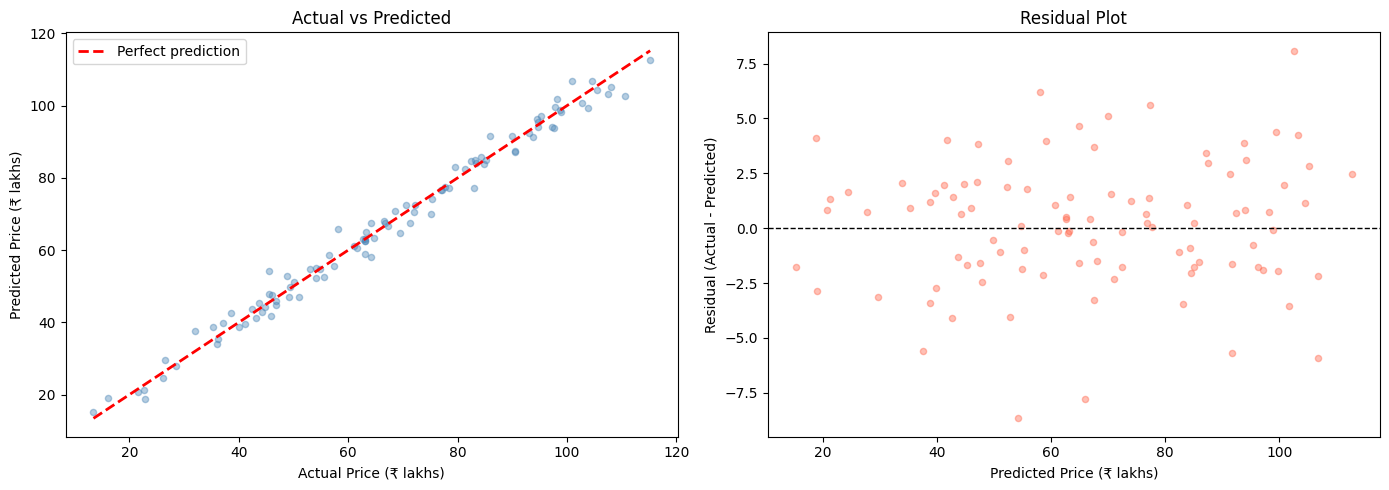

In [9]:
# ── Step 8: Visualise Predictions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (₹ lakhs)')
axes[0].set_ylabel('Predicted Price (₹ lakhs)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='tomato', s=20)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Price (₹ lakhs)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

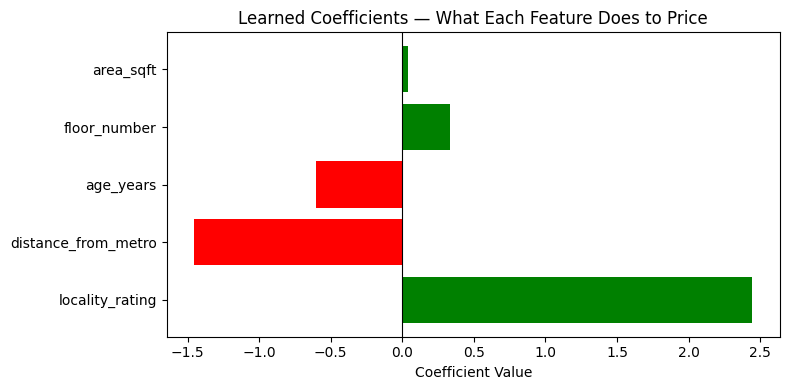


How to read the coefficients:
  1 unit increase in locality_rating           adds price by ₹2.4429 lakhs
  1 unit increase in distance_from_metro       reduces price by ₹1.4513 lakhs
  1 unit increase in age_years                 reduces price by ₹0.6005 lakhs
  1 unit increase in floor_number              adds price by ₹0.3335 lakhs
  1 unit increase in area_sqft                 adds price by ₹0.0397 lakhs


In [10]:
# ── Step 9: Coefficient Interpretation ───────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Learned Coefficients — What Each Feature Does to Price')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\nHow to read the coefficients:")
for feat, coef in zip(coef_df['Feature'], coef_df['Coefficient']):
    direction = "adds" if coef > 0 else "reduces"
    print(f"  1 unit increase in {feat:<25} {direction} price by ₹{abs(coef):.4f} lakhs")

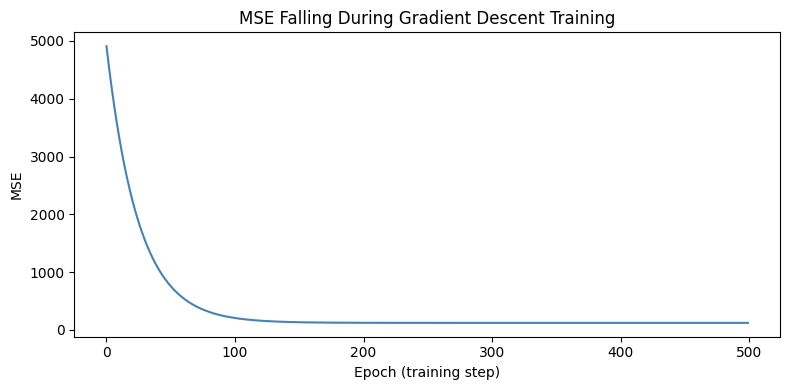

Final w: 22.4106
Final b: 65.4516
MSE kept falling — model was learning with every step.


In [11]:
# ── Step 10: From Scratch — Gradient Descent ─────────────────────────────────
# Shows what happens under the hood during training
# Using one feature (area_sqft) for simplicity

X_scratch = df['area_sqft'].values.reshape(-1, 1)
y_scratch = df['price_lakhs'].values

X_norm = (X_scratch - X_scratch.mean()) / X_scratch.std()

w = 0.0
b = 0.0
lr = 0.01
n  = len(X_norm)
mse_history = []

for epoch in range(500):
    y_hat = w * X_norm.flatten() + b
    mse = np.mean((y_scratch - y_hat) ** 2)
    mse_history.append(mse)
    dw = (-2/n) * np.sum((y_scratch - y_hat) * X_norm.flatten())
    db = (-2/n) * np.sum(y_scratch - y_hat)
    w = w - lr * dw
    b = b - lr * db

plt.figure(figsize=(8, 4))
plt.plot(mse_history, color='steelblue')
plt.title('MSE Falling During Gradient Descent Training')
plt.xlabel('Epoch (training step)')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

print(f"Final w: {w:.4f}")
print(f"Final b: {b:.4f}")
print("MSE kept falling — model was learning with every step.")

---

## Summary Table

| | Linear Regression |
|---|---|
| **Task** | Predict a continuous number |
| **Equation** | $\hat{y} = w_1x_1 + w_2x_2 + \cdots + b$ |
| **Loss function** | $MSE = \frac{1}{n}\sum(y - \hat{y})^2$ |
| **How it learns** | Normal Equation (exact) or Gradient Descent (iterative) |
| **Normal Equation cost** | $O(n^3)$ — breaks for huge feature counts |
| **Strength** | Simple, fast, perfectly interpretable coefficients |
| **Weakness** | Overfits with many/correlated features; assumes linearity |
| **When to use** | First model to try for any regression problem |
| **When NOT to use** | Many correlated features → use Ridge (5.2) instead |
| **scaler.fit(X)** | Learns mean and std — for scaling only |
| **model.fit(X,y)** | Solves Normal Equation — finds best coefficients |

---

## What's Next?

Linear Regression's biggest weakness: **no control over coefficient size.**

With correlated features, coefficients blow up — one becomes +800, another −750 — wild, unstable, uninterpretable.

**5.2 Ridge Regression** fixes this by adding a penalty that forces coefficients to stay small.

---

## Practice Task

Meena is building a model to predict **student exam scores** (out of 100) based on:
- `study_hours` — hours studied per day
- `sleep_hours` — hours slept the night before
- `distance_from_school_km` — how far they travel
- `attendance_pct` — % of classes attended

**Your tasks:**

1. Create a synthetic dataset of 300 students with a realistic formula
2. Train a Linear Regression model
3. Print the learned coefficients and interpret them in plain English
4. Evaluate with RMSE and R²
5. Plot Actual vs Predicted
6. Which feature has the highest positive impact on score?

In [ ]:
# YOUR CODE HERE

# Step 1: Create dataset

# Step 2: Train model

# Step 3: Print and interpret coefficients

# Step 4: Evaluate

# Step 5: Plot

# Step 6: Answer — which feature matters most?